## 7. Social Vulnerability Analysis

This section uses ABS Census data to measure social vulnerability at the SA2 level. The indicators include median household income, elderly population percentage, children population percentage and population density. This part is later used as one input for the final priority intervention index.

### 7.1 Load packages and set folders

In [82]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os

In [83]:
# set folder paths
raw_path = "../data/raw"
processed_path = "../data/processed"
figure_path = "../output/figures"
table_path = "../output/tables"

# make folders for processed data and outputs
os.makedirs(processed_path, exist_ok=True)
os.makedirs(figure_path, exist_ok=True)
os.makedirs(table_path, exist_ok=True)

### 7.2 Load and prepare SA2 boundary

In [84]:
# load final study area boundary
sa2_melb = gpd.read_file(raw_path + "/boundary/study_area.gpkg")
# check first few rows
sa2_melb.head()

,id,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.66540 -37.87010, 144.66529..."
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.73479 -37.94361, 144.73479..."
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.64116 -37.88193, 144.64109..."
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.59729 -37.94211, 144.59733..."
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.51648 -37.87412, 144.54997..."


In [85]:
# check column names
sa2_melb.columns

Index(['id', 'SA2_CODE_2021', 'SA2_NAME_2021', 'CHANGE_FLAG_2021',
       'CHANGE_LABEL_2021', 'SA3_CODE_2021', 'SA3_NAME_2021', 'SA4_CODE_2021',
       'SA4_NAME_2021', 'GCCSA_CODE_2021', 'GCCSA_NAME_2021',
       'STATE_CODE_2021', 'STATE_NAME_2021', 'AUS_CODE_2021', 'AUS_NAME_2021',
       'AREA_ALBERS_SQKM', 'ASGS_LOCI_URI_2021', 'geometry'],
      dtype='object')

In [86]:
# rename columns to simple names
sa2_melb = sa2_melb.rename(columns={
    "SA2_CODE_2021": "sa2_code",
    "SA2_NAME_2021": "sa2_name"})

In [87]:
# Read original boundary again to get official SA2 area

sa2_area = gpd.read_file(raw_path + "/boundary/study_area.gpkg")
sa2_area = sa2_area[[ "SA2_CODE_2021", "AREA_ALBERS_SQKM"]].copy()
sa2_area = sa2_area.rename(columns={"SA2_CODE_2021": "sa2_code", "AREA_ALBERS_SQKM": "area_km2"})
sa2_area["sa2_code"] = sa2_area["sa2_code"].astype(str)

# remove old area_km2 if it was calculated from clipped geometry
sa2_melb = sa2_melb.drop(columns=["area_km2"], errors="ignore")

sa2_melb = sa2_melb.merge( sa2_area, on="sa2_code",how="left" )

sa2_melb.head()

,id,sa2_code,sa2_name,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,area_km2
0,1081,213051362,Hoppers Crossing - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.0114,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.66540 -37.87010, 144.66529...",7.0114
1,1083,213051368,Werribee - South,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,114.0332,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.73479 -37.94361, 144.73479...",114.0332
2,1086,213051467,Werribee - East,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,7.7569,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.64116 -37.88193, 144.64109...",7.7569
3,1087,213051468,Werribee - West,0,No change,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,127.6631,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.59729 -37.94211, 144.59733...",127.6631
4,1088,213051579,Manor Lakes - Quandong,1,New,21305,Wyndham,213,Melbourne - West,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,72.0339,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((144.51648 -37.87412, 144.54997...",72.0339


In [88]:
# save cleaned SA2 boundary
sa2_melb.to_file(
    processed_path + "/sa2_melbourne_clean.gpkg",
    driver="GPKG")

The study area boundary was provided as a prepared SA2 layer. It was used as the spatial base for joining Census indicators.

### 7.3 Load Census tables
The Census G01 table was used for age and population variables. The G02 table was used for median weekly household income.

In [89]:
# read G01 and G02 census tables
g01 = pd.read_csv(raw_path + "/census/2021Census_G01_VIC_SA2.csv")
g02 = pd.read_csv(raw_path + "/census/2021Census_G02_VIC_SA2.csv")

g01.head()

,SA2_CODE_2021,Tot_P_M,Tot_P_F,Tot_P_P,Age_0_4_yr_M,Age_0_4_yr_F,Age_0_4_yr_P,Age_5_14_yr_M,Age_5_14_yr_F,Age_5_14_yr_P,...,High_yr_schl_comp_Yr_8_belw_P,High_yr_schl_comp_D_n_g_sch_M,High_yr_schl_comp_D_n_g_sch_F,High_yr_schl_comp_D_n_g_sch_P,Count_psns_occ_priv_dwgs_M,Count_psns_occ_priv_dwgs_F,Count_psns_occ_priv_dwgs_P,Count_Persons_other_dwgs_M,Count_Persons_other_dwgs_F,Count_Persons_other_dwgs_P
0,201011001,8188,8648,16835,623,585,1213,1453,1364,2815,...,430,23,22,45,7786,8263,16055,268,313,585
1,201011002,5711,6420,12131,267,224,490,658,630,1290,...,355,10,13,22,5152,5811,10969,755,766,1521
2,201011005,3594,3664,7261,190,172,357,561,587,1148,...,169,10,8,14,3308,3417,6722,217,215,435
3,201011006,5111,5553,10661,382,426,804,784,683,1464,...,408,22,13,39,4837,5211,10052,227,270,501
4,201011007,2172,2055,4230,125,99,223,338,326,668,...,126,4,3,8,2099,2013,4107,37,37,71


### 7.4 Prepare age and population indicators

In [90]:
g01_clean = g01.copy()
g01_clean["sa2_code"] = g01_clean["SA2_CODE_2021"].astype(str)

# calculate children population(children are defined as people aged 0 to 14)
g01_clean["children_pop"] = (
    g01_clean["Age_0_4_yr_P"] +
    g01_clean["Age_5_14_yr_P"])

# calculate elderly population(elderly people are defined as people aged 65 and over)
g01_clean["elderly_pop"] = (
    g01_clean["Age_65_74_yr_P"] +
    g01_clean["Age_75_84_yr_P"] +
    g01_clean["Age_85ov_P"])

# total population
g01_clean["total_population"] = g01_clean["Tot_P_P"]

# calculate percentage
g01_clean["children_pct"] = (g01_clean["children_pop"] / g01_clean["total_population"] * 100)

g01_clean["elderly_pct"] = (g01_clean["elderly_pop"] / g01_clean["total_population"] * 100)

# keep useful columns
g01_clean = g01_clean[
    [
        "sa2_code",
        "children_pop",
        "elderly_pop",
        "total_population",
        "children_pct",
        "elderly_pct"]]

g01_clean.head()

,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct
0,201011001,4028,2178,16835,23.926344,12.937333
1,201011002,1780,2826,12131,14.673151,23.295689
2,201011005,1505,1334,7261,20.727173,18.372125
3,201011006,2268,1578,10661,21.273802,14.801613
4,201011007,891,608,4230,21.063830,14.373522


Median weekly household income was selected as the income indicator. A lower income is later treated as higher vulnerability.

In [91]:
g02_clean = g02.copy()
g02_clean["sa2_code"] = g02_clean["SA2_CODE_2021"].astype(str)

# use median household income
g02_clean["median_income"] = g02_clean["Median_tot_hhd_inc_weekly"]
# keep useful columns
g02_clean = g02_clean[[ "sa2_code","median_income"]]

g02_clean.head()

,sa2_code,median_income
0,201011001,1952
1,201011002,1573
2,201011005,1927
3,201011006,1627
4,201011007,2065


In [92]:
# merge age/population table with income table
census_clean = g01_clean.merge(
    g02_clean,
    on="sa2_code",
    how="left")

census_clean.head()

,sa2_code,children_pop,elderly_pop,total_population,children_pct,elderly_pct,median_income
0,201011001,4028,2178,16835,23.926344,12.937333,1952
1,201011002,1780,2826,12131,14.673151,23.295689,1573
2,201011005,1505,1334,7261,20.727173,18.372125,1927
3,201011006,2268,1578,10661,21.273802,14.801613,1627
4,201011007,891,608,4230,21.063830,14.373522,2065


In [93]:
# remove rows with missing values in selected indicators
census_clean = census_clean.dropna(
    subset=["children_pct", "elderly_pct", "total_population", "median_income"])

### 7.5 Join Census indicators to SA2 boundary

In [94]:
# merge census data with SA2 boundary
sa2_census = sa2_melb.merge(
    census_clean,
    on="sa2_code",
    how="left")

# calculate population density
sa2_census["population_density"] = (sa2_census["total_population"] / sa2_census["area_km2"])

sa2_census[[
        "sa2_code",
        "sa2_name",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"]].head()

,sa2_code,sa2_name,median_income,children_pct,elderly_pct,population_density
0,213051362,Hoppers Crossing - South,1470.0,19.470488,15.619007,2677.354023
1,213051368,Werribee - South,1802.0,18.887567,15.425342,147.413209
2,213051467,Werribee - East,1374.0,19.495003,15.228827,2450.721293
3,213051468,Werribee - West,1995.0,23.123405,8.030079,174.999667
4,213051579,Manor Lakes - Quandong,2309.0,30.519970,3.570083,147.375055


Population density was calculated using the official `AREA_ALBERS_SQKM` field from the SA2 boundary file. This was used instead of geometry area because some edge SA2 geometries may be clipped in the working study area boundary. Since Census population represents the full SA2 population, using the official SA2 area gives a more reasonable density estimate.

In [96]:
# check missing values after joining
sa2_census[
    ["median_income", "children_pct", "elderly_pct", "population_density"]].isna().sum()

median_income         2
children_pct          2
elderly_pct           2
population_density    2
dtype: int64

In [97]:
# check which SA2s have missing census data
missing_census = sa2_census[sa2_census["median_income"].isna()][["sa2_code", "sa2_name", "area_km2"]]
missing_census

,sa2_code,sa2_name,area_km2
88,206041127,West Melbourne - Industrial,6.1992
187,206041507,Royal Botanic Gardens Victoria,1.3511


Two SA2s did not have matched Census values after joining the Census data to the study area boundary. These were West Melbourne - Industrial and Royal Botanic Gardens Victoria. They were removed before calculating the social vulnerability score because all selected indicators were required for the index calculation.

In [98]:
# remove SA2s with missing census indicators
sa2_census = sa2_census.dropna(
    subset=[
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density"]).copy()
# check number of SA2s after removing missing rows
len(sa2_census)

358

In [100]:
# check missing values again after removing missing rows
sa2_census[["median_income", "children_pct", "elderly_pct", "population_density"]].isna().sum()

median_income         0
children_pct          0
elderly_pct           0
population_density    0
dtype: int64

### 7.6 Calculate social vulnerability score

All indicators were standardised to a 0–1 scale before calculating the score. Income was reversed because lower income means higher vulnerability. Elderly percentage, children percentage and population density were treated as positive indicators, where higher values mean higher vulnerability or exposure.

In [101]:
# function for min-max standardisation
def standardise(column):
    return (column - column.min()) / (column.max() - column.min())

# reverse standardisation
def reverse_standardise(column):
    return (column.max() - column) / (column.max() - column.min())

In [102]:
# calculate vulnerability scores
sa2_census["income_score"] = reverse_standardise(sa2_census["median_income"])
sa2_census["elderly_score"] = standardise(sa2_census["elderly_pct"])
sa2_census["children_score"] = standardise(sa2_census["children_pct"])
sa2_census["density_score"] = standardise(sa2_census["population_density"])

# calculate final social vulnerability score
sa2_census["social_vulnerability_score"] = (
    sa2_census["income_score"] +
    sa2_census["elderly_score"] +
    sa2_census["children_score"] +
    sa2_census["density_score"]) / 4

**Table X. Top 10 SA2s with the highest social vulnerability score.**

In [103]:
# make top 10 social vulnerability table
top_social = sa2_census.sort_values(
    by="social_vulnerability_score",
    ascending=False
).head(10)

top_social_table = top_social[
    [ "sa2_name",
        "median_income",
        "elderly_pct",
        "children_pct",
        "population_density",
        "social_vulnerability_score"]].copy()

top_social_table

,sa2_name,median_income,elderly_pct,children_pct,population_density,social_vulnerability_score
162,Rosebud - McCrae,1155.0,33.372559,14.029812,964.207819,0.483843
185,Mornington - West,1389.0,38.701446,10.802382,1652.145400,0.478759
11,Point Nepean,1430.0,32.239665,13.871082,294.860956,0.446123
20,Melton,1061.0,20.213036,18.792797,799.683615,0.442658
196,Melbourne CBD - North,1089.0,1.920569,2.744517,30039.173789,0.440371
184,Mornington - East,1502.0,26.003295,17.930807,1033.128183,0.437451
163,Dromana,1398.0,30.734700,13.444561,296.643178,0.435837
59,Campbellfield - Coolaroo,1104.0,15.638039,21.679018,882.897942,0.432606
140,Avondale Heights,1587.0,26.727478,15.975137,2290.384011,0.430057
68,Kings Park (Vic.),1246.0,17.571337,18.665522,3154.795479,0.428332


In [104]:
# save top 10 table
top_social_table.to_csv(
    table_path + "/top_10_social_vulnerability_SA2.csv",
    index=False)

In [105]:
# save census indicators for later merge
sa2_census.drop(columns="geometry").to_csv(
    processed_path + "/census_indicators_by_SA2.csv",
    index=False)

### 7.7 Map social vulnerability

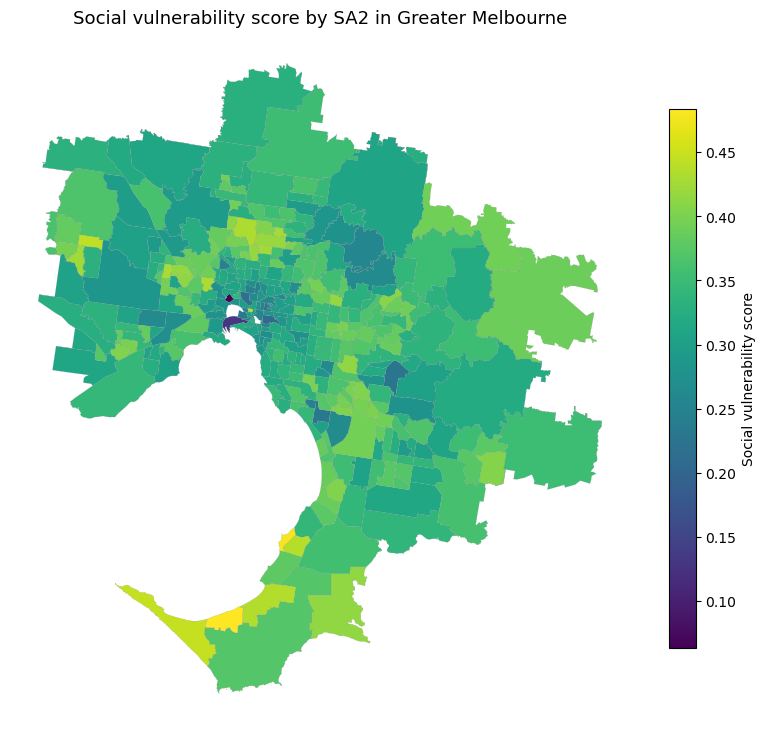

In [106]:
fig, ax = plt.subplots(figsize=(10, 10))

sa2_census.plot(
    column="social_vulnerability_score",
    legend=True,
    legend_kwds={
        "label": "Social vulnerability score",
        "shrink": 0.7},
    edgecolor="grey",
    linewidth=0.1,
    ax=ax)

ax.set_title("Social vulnerability score by SA2 in Greater Melbourne", fontsize=13)
ax.axis("off")

fig.savefig(
    figure_path + "/social_vulnerability_map.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Figure X. Social vulnerability score by SA2 in Greater Melbourne.**  
Higher values show SA2s with higher social vulnerability based on weekly median household income, elderly population percentage, children population percentage and population density.

In [107]:
# Save social vulnerability layer with geometry
sa2_census.to_file( processed_path + "/social_vulnerability_SA2.gpkg", driver="GPKG")

The social vulnerability layer was saved as a GeoPackage so that it can be joined with the green space and urban heat results in the next step.

### 7.8 Join social vulnerability with green space and urban heat

In [108]:
# Read Q2 green space and urban heat result from teammate

q2_path = "../notebooks/q2_green_heat.gpkg"
q2_green_heat = gpd.read_file(q2_path)
q2_green_heat.head()

,sa2_code,sa2_name,coverage,open_area,UHI18_M,geometry
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,"MULTIPOLYGON (((16104078.525 -4561091.453, 161..."
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,"MULTIPOLYGON (((16111802.697 -4571463.547, 161..."
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,"MULTIPOLYGON (((16101380.797 -4562759.439, 161..."
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,"MULTIPOLYGON (((16096496.805 -4571250.532, 160..."
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,"MULTIPOLYGON (((16125943.474 -4643363.334, 161..."


In [109]:
# Check number of SA2 areas in Q2 result
print("Number of SA2 areas in Q2 green heat result:", len(q2_green_heat))
print(q2_green_heat.crs)

Number of SA2 areas in Q2 green heat result: 257
EPSG:3857


The Q2 green space and urban heat result was loaded from the shared GitHub file. This dataset includes open space coverage, open space area and urban heat intensity for the matched SA2 areas. This final analysis is based on the 257 matched SA2 areas from the Q2 green space and urban heat dataset. Therefore, the result does not cover every SA2 in the original Greater Melbourne boundary.

In [110]:
q2_green_heat["sa2_code"] = q2_green_heat["sa2_code"].astype(str)
sa2_census["sa2_code"] = sa2_census["sa2_code"].astype(str)

# Join Q2 result with social vulnerability result
final = q2_green_heat.merge(
    sa2_census[
        [ "sa2_code",
            "median_income",
            "children_pct",
            "elderly_pct",
            "population_density",
            "total_population",
            "social_vulnerability_score"]],
    on="sa2_code",
    how="left")

final.head()

,sa2_code,sa2_name,coverage,open_area,UHI18_M,geometry,median_income,children_pct,elderly_pct,population_density,total_population,social_vulnerability_score
0,213051362,Hoppers Crossing - South,11.790865,8.268239e+05,8.385504,"MULTIPOLYGON (((16104078.525 -4561091.453, 161...",1470.0,19.470488,15.619007,2677.354023,18772.0,0.398804
1,213051368,Werribee - South,61.657575,7.032759e+07,6.900058,"MULTIPOLYGON (((16111802.697 -4571463.547, 161...",1802.0,18.887567,15.425342,147.413209,16810.0,0.343468
2,213051467,Werribee - East,21.359952,1.657223e+06,7.630220,"MULTIPOLYGON (((16101380.797 -4562759.439, 161...",1374.0,19.495003,15.228827,2450.721293,19010.0,0.402824
3,213051468,Werribee - West,42.719471,2.559582e+07,8.069294,"MULTIPOLYGON (((16096496.805 -4571250.532, 160...",1995.0,23.123405,8.030079,174.999667,22341.0,0.312386
4,214021383,Point Nepean,30.647845,2.059349e+07,3.073223,"MULTIPOLYGON (((16125943.474 -4643363.334, 161...",1430.0,13.871082,32.239665,294.860956,19811.0,0.446123


In [111]:
# Check missing values after joining

print(final.shape)

final[[ "coverage",
        "open_area",
        "UHI18_M",
        "median_income",
        "children_pct",
        "elderly_pct",
        "population_density",
        "total_population",
        "social_vulnerability_score"]].isna().sum()

(257, 12)


coverage                      0
open_area                     0
UHI18_M                       0
median_income                 0
children_pct                  0
elderly_pct                   0
population_density            0
total_population              0
social_vulnerability_score    0
dtype: int64

The Q2 result was joined with the social vulnerability indicators using SA2 code. This creates one dataset containing green space, urban heat and social vulnerability variables. This dataset will be used to identify areas where environmental and social disadvantages overlap.

In [112]:
# Calculate green space per person

final["green_space_per_person"] = (final["open_area"] / final["total_population"])

final[["sa2_name",
        "open_area",
        "total_population",
        "coverage",
        "green_space_per_person"]].head()

,sa2_name,open_area,total_population,coverage,green_space_per_person
0,Hoppers Crossing - South,8.268239e+05,18772.0,11.790865,44.045596
1,Werribee - South,7.032759e+07,16810.0,61.657575,4183.675934
2,Werribee - East,1.657223e+06,19010.0,21.359952,87.176370
3,Werribee - West,2.559582e+07,22341.0,42.719471,1145.688078
4,Point Nepean,2.059349e+07,19811.0,30.647845,1039.497502


Green space per person was calculated by dividing total open space area by total population. This gives a population-adjusted measure of green space availability. It is useful for the equity analysis because open space coverage alone does not show how many people share the available green space.

In [113]:
# Remove rows with missing values for final priority analysis

final_clean = final.dropna(
    subset=[
        "coverage",
        "open_area",
        "UHI18_M",
        "total_population",
        "green_space_per_person",
        "social_vulnerability_score"]).copy()

print("Before removing missing values:", len(final))
print("After removing missing values:", len(final_clean))

Before removing missing values: 257
After removing missing values: 257


Rows with missing values were removed before calculating the final priority score. This is needed because the priority score combines several indicators, and missing values would affect the calculation.

In [114]:
# Standardise indicators for final priority score

final_clean["heat_score"] = standardise(final_clean["UHI18_M"])
final_clean["low_coverage_score"] = reverse_standardise(final_clean["coverage"])
final_clean["low_green_per_person_score"] = reverse_standardise(final_clean["green_space_per_person"])
final_clean["social_score"] = standardise(final_clean["social_vulnerability_score"])
final_clean[[ "sa2_name",
        "heat_score",
        "low_coverage_score",
        "low_green_per_person_score",
        "social_score"]].head()

,sa2_name,heat_score,low_coverage_score,low_green_per_person_score,social_score
0,Hoppers Crossing - South,0.715014,0.840835,0.999674,0.797695
1,Werribee - South,0.587907,0.167683,0.969047,0.666054
2,Werribee - East,0.650386,0.711662,0.999355,0.807260
3,Werribee - West,0.687956,0.423329,0.991524,0.592111
4,Point Nepean,0.260452,0.586284,0.992309,0.910267


The indicators were standardised to a 0–1 scale before calculating the final priority score. Urban heat and social vulnerability were treated as positive indicators, where higher values mean higher priority. Open space coverage and green space per person were reversed, because lower green space availability means higher need for intervention.

In [115]:
# Calculate final priority intervention score

final_clean["priority_score"] = (final_clean["heat_score"] + final_clean["low_coverage_score"] + final_clean["low_green_per_person_score"] + final_clean["social_score"]) / 4
final_clean[[
        "sa2_name",
        "UHI18_M",
        "coverage",
        "green_space_per_person",
        "social_vulnerability_score",
        "priority_score"]].head()

,sa2_name,UHI18_M,coverage,green_space_per_person,social_vulnerability_score,priority_score
0,Hoppers Crossing - South,8.385504,11.790865,44.045596,0.398804,0.838305
1,Werribee - South,6.900058,61.657575,4183.675934,0.343468,0.597673
2,Werribee - East,7.630220,21.359952,87.176370,0.402824,0.792165
3,Werribee - West,8.069294,42.719471,1145.688078,0.312386,0.673730
4,Point Nepean,3.073223,30.647845,1039.497502,0.446123,0.687328


The final priority intervention score was calculated as the average of heat exposure, low open space coverage, low green space per person and social vulnerability. Equal weighting was used to keep the method simple and transparent.

In [116]:
# Top 10 priority areas
top_priority = final_clean.sort_values( by="priority_score", ascending=False).head(10)
top_priority_table = top_priority[[
        "sa2_name",
        "UHI18_M",
        "coverage",
        "green_space_per_person",
        "social_vulnerability_score",
        "priority_score"]].copy()

top_priority_table

,sa2_name,UHI18_M,coverage,green_space_per_person,social_vulnerability_score,priority_score
101,St Albans - North,10.610981,5.891464,18.672790,0.415288,0.915672
8,Melton,10.901197,15.500625,193.895584,0.442658,0.905405
111,Burnside,11.348166,7.605777,33.472262,0.372398,0.900121
39,Kings Park (Vic.),10.967239,16.103500,51.048446,0.428332,0.896528
37,Delahey,11.409298,8.771380,38.074284,0.366621,0.894051
7,Melton West,11.451552,13.209407,150.797118,0.382278,0.889081
23,Tullamarine,9.889888,5.812658,34.117733,0.391998,0.886632
6,Bacchus Marsh,9.601099,0.025371,0.128794,0.362938,0.882765
249,Noble Park - West,9.471841,5.862634,14.343045,0.396210,0.880062
105,Sunshine West,10.234022,9.697581,67.777624,0.387965,0.878422


In [117]:
# Save top 10 priority table

top_priority_table.to_csv(table_path + "/top_10_priority_intervention_SA2.csv",index=False)

The top 10 table shows SA2 areas with the highest combined priority scores. These areas have relatively high heat intensity, lower green space availability and higher social vulnerability. They can be considered possible priority locations for future greening and heat mitigation planning.

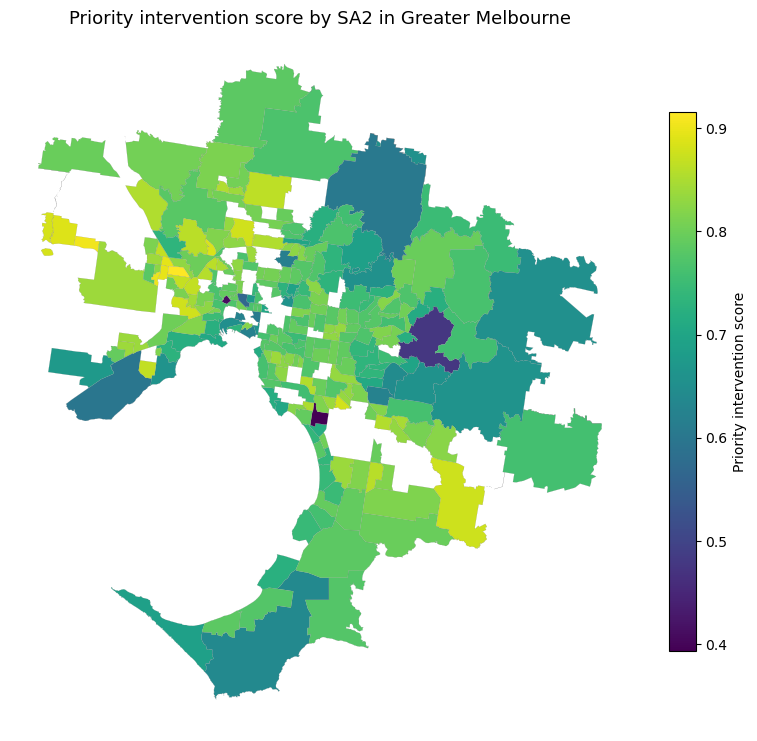

In [118]:
# Map final priority score
fig, ax = plt.subplots(figsize=(10, 10))
final_clean.plot(
    column="priority_score",
    legend=True,
    legend_kwds={
        "label": "Priority intervention score",
        "shrink": 0.7},
    edgecolor="grey",
    linewidth=0.1,
    ax=ax)

ax.set_title("Priority intervention score by SA2 in Greater Melbourne", fontsize=13)
ax.axis("off")

fig.savefig(figure_path + "/priority_intervention_map.png",
    dpi=300, bbox_inches="tight")

plt.show()

**Figure X. Priority intervention score by SA2 in Greater Melbourne.**  
Higher values indicate SA2s with higher combined priority based on urban heat intensity, low open space coverage, low green space per person and social vulnerability.

### 7.9 Conclusion

This section developed a simple social vulnerability and priority intervention analysis at the SA2 level. The social vulnerability score was based on median household income, elderly population percentage, children population percentage and population density. These indicators were used to represent socio-economic capacity, heat sensitivity and population exposure.

The final priority intervention score combined social vulnerability with environmental indicators from Q2, including urban heat intensity, open space coverage and green space per person. The results show that priority areas are not only defined by high heat, but by the overlap between heat exposure, limited green space availability and social vulnerability.

This analysis is useful as a first-stage screening tool for urban greening and heat mitigation planning. However, the result should be interpreted carefully because it uses equal weighting, SA2-level data and only the 257 SA2 areas matched in the Q2 dataset. Future analysis could include tree canopy cover, park accessibility, building density and more detailed local-scale demographic data. Green space per person also has some high values in outer SA2 areas, so the standardised score may be affected by outliers.